# 03 · Stationarity Testing and SARIMA Model Selection

In [2]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tools.sm_exceptions import InterpolationWarning, ConvergenceWarning

DATA_DIR = "data"
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

TRAIN_END = '2023-12-31'      # training data: Jan 2019 – Dec 2023
SELECT_END = '2022-12-31'     # for choosing the enforce setting: fit up to 2022 ...
VALID_START = '2023-01-01'    # ... and validate on 2023

In [3]:
df = pd.read_csv(os.path.join(DATA_DIR, "aqi_master_clean.csv"), parse_dates=['Date'])

monthly_df = (
    df.groupby(['City', pd.Grouper(key='Date', freq='MS')])['AQI']
      .mean()
      .reset_index()
)
cities = sorted(monthly_df['City'].unique())

def city_series(city):
    s = (monthly_df[monthly_df['City'] == city]
         .set_index('Date')['AQI']
         .sort_index())
    s.index.freq = 'MS'
    return s

print({c: len(city_series(c)) for c in cities}, "monthly observations per city")

{'Bengaluru': 75, 'Delhi': 75, 'Kolkata': 75, 'Mumbai': 75} monthly observations per city


## 1. STL decomposition
Visual check of trend and seasonality. Note any unusual residuals, for example around the 2020 lockdown.

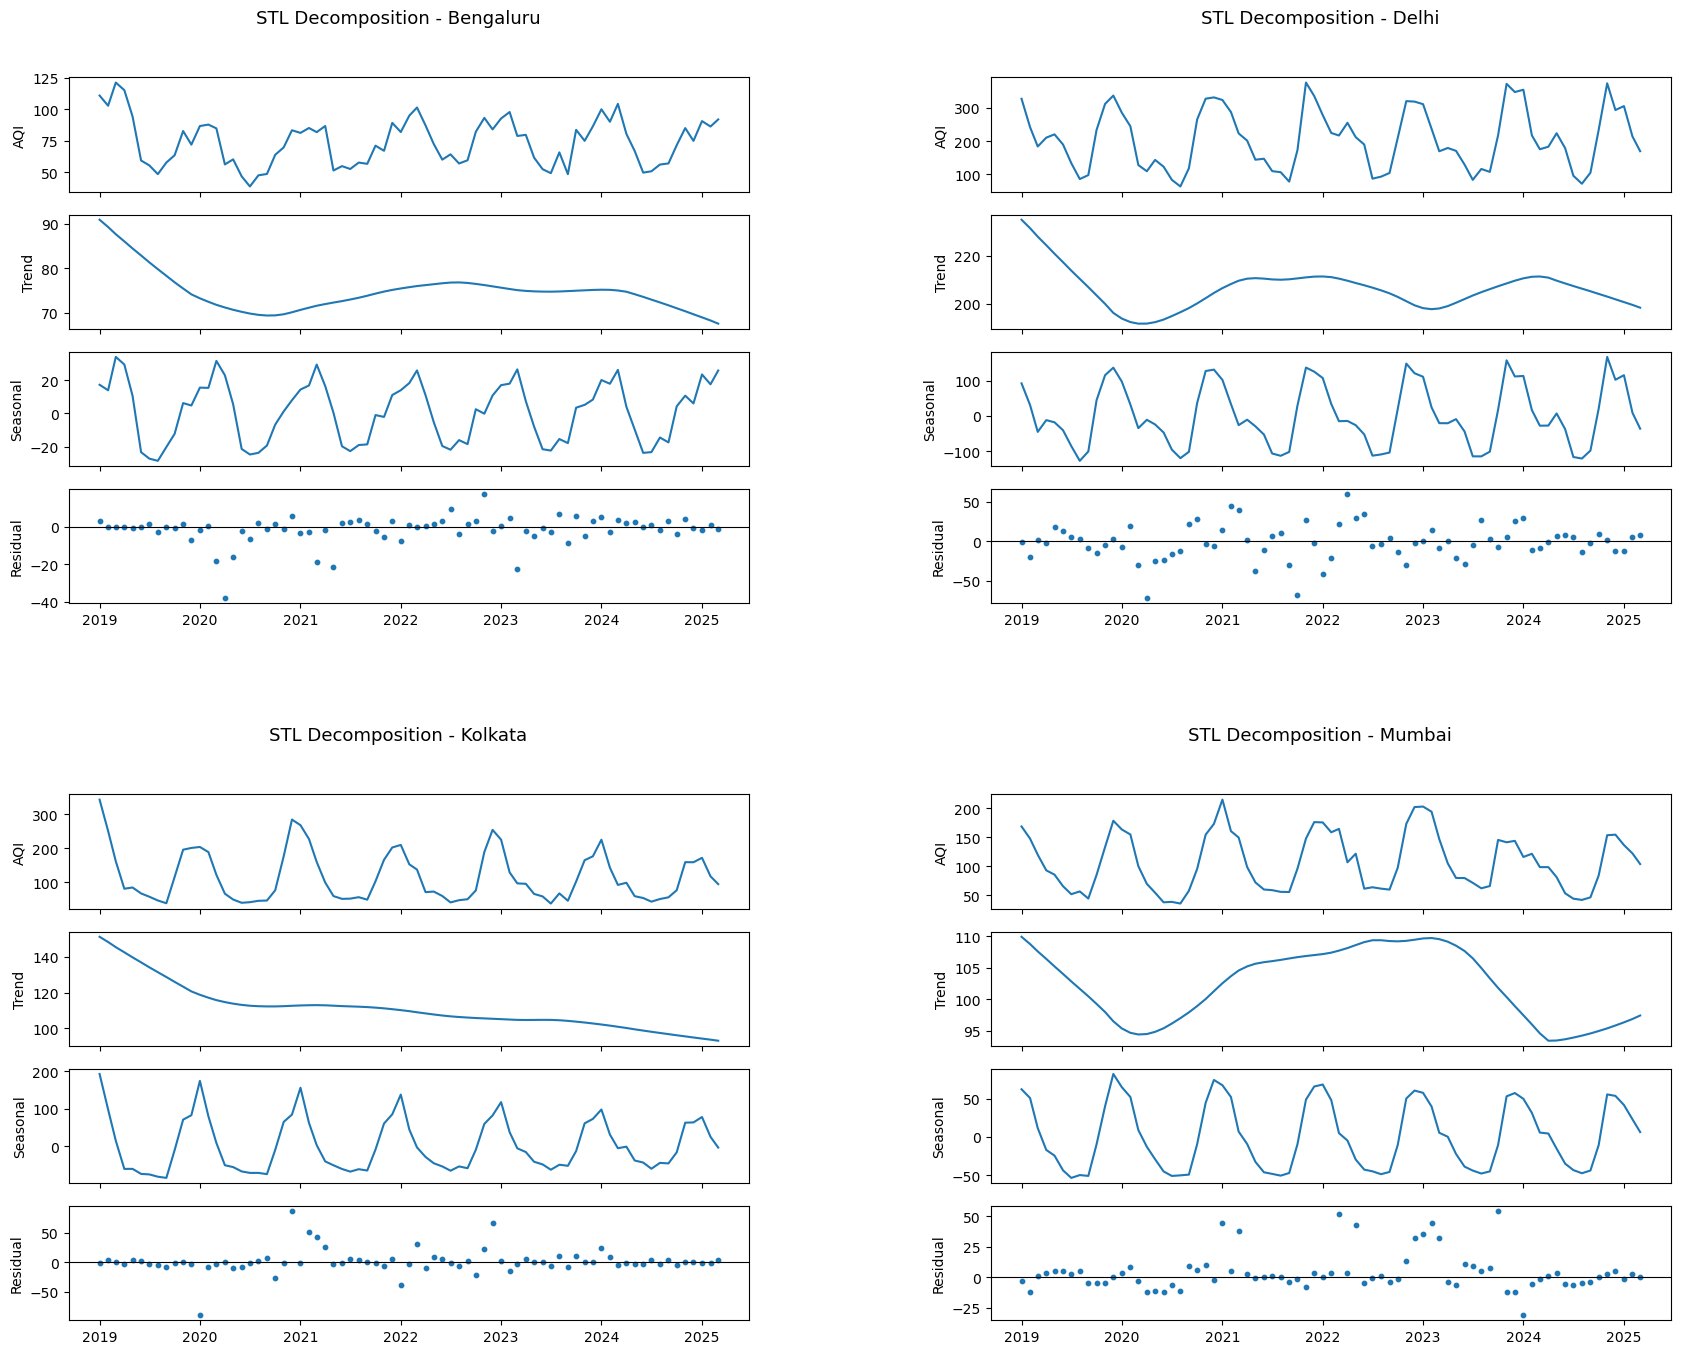

In [5]:
fig = plt.figure(figsize=(18, 14))
subfigs = fig.subfigures(2, 2, hspace=0.05, wspace=0.05)

for subfig, city in zip(subfigs.flat, cities):
    result = STL(city_series(city), period=12, robust=True).fit()

    axes = subfig.subplots(4, 1, sharex=True)
    parts = [
        (result.observed, 'AQI'),
        (result.trend, 'Trend'),
        (result.seasonal, 'Seasonal'),
        (result.resid, 'Residual'),
    ]

    for ax, (data, label) in zip(axes, parts):
        if label == 'Residual':
            ax.scatter(data.index, data, s=10)
            ax.axhline(0, color='black', linewidth=0.8)
        else:
            ax.plot(data)
        ax.set_ylabel(label)

    subfig.suptitle(f'STL Decomposition - {city}', fontsize=13)

plt.show()

## 2. ADF and KPSS tests

- **ADF:** null hypothesis = unit root. p < 0.05 → evidence of stationarity.
- **KPSS:** null hypothesis = stationary. p < 0.05 → evidence of non-stationarity.
- statsmodels caps the KPSS p-value at 0.10. A value of 0.10 means "at least 0.10", shown as `>=0.10`.

In [7]:
def run_tests(series):
    adf_stat, adf_p = adfuller(series.dropna())[:2]
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", InterpolationWarning)
        kpss_stat, kpss_p = kpss(series.dropna(), regression='c', nlags='auto')[:2]
    return {
        'ADF_Stat': round(adf_stat, 4),
        'ADF_p': round(adf_p, 4),
        'ADF_Decision': 'Stationary' if adf_p < 0.05 else 'Non-stationary',
        'KPSS_Stat': round(kpss_stat, 4),
        'KPSS_p': '>=0.10' if kpss_p >= 0.1 else ('<=0.01' if kpss_p <= 0.01 else round(kpss_p, 4)),
        'KPSS_Decision': 'Stationary' if kpss_p >= 0.05 else 'Non-stationary',
    }

rows = []
for city in cities:
    s = city_series(city)
    rows.append({'City': city, 'Series': 'Level', **run_tests(s)})
    rows.append({'City': city, 'Series': 'First difference', **run_tests(s.diff())})

stationarity_results = pd.DataFrame(rows)
stationarity_results.to_csv(os.path.join(RESULTS_DIR, "stationarity_results.csv"), index=False)
stationarity_results

,City,Series,ADF_Stat,ADF_p,ADF_Decision,KPSS_Stat,KPSS_p,KPSS_Decision
0,Bengaluru,Level,-7.0315,0.0000,Stationary,0.0646,>=0.10,Stationary
1,Bengaluru,First difference,-5.5712,0.0000,Stationary,0.0767,>=0.10,Stationary
2,Delhi,Level,-2.2292,0.1958,Non-stationary,0.0298,>=0.10,Stationary
3,Delhi,First difference,-4.4586,0.0002,Stationary,0.0269,>=0.10,Stationary
4,Kolkata,Level,-1.4875,0.5397,Non-stationary,0.0807,>=0.10,Stationary
5,Kolkata,First difference,-3.3920,0.0112,Stationary,0.0716,>=0.10,Stationary
6,Mumbai,Level,-1.0500,0.7346,Non-stationary,0.0406,>=0.10,Stationary
7,Mumbai,First difference,-7.4337,0.0000,Stationary,0.0308,>=0.10,Stationary


## 3. Seasonal differencing tests (OCSB and Canova-Hansen)

In [9]:
try:
    from pmdarima.arima.utils import nsdiffs
    seasonal_rows = []
    for city in cities:
        s = city_series(city)
        seasonal_rows.append({
            'City': city,
            'OCSB_D': nsdiffs(s, m=12, test='ocsb'),
            'CH_D': nsdiffs(s, m=12, test='ch'),
        })
    seasonal_tests = pd.DataFrame(seasonal_rows)
    seasonal_tests.to_csv(os.path.join(RESULTS_DIR, "seasonal_diff_tests.csv"), index=False)
    display(seasonal_tests)
except ImportError:
    print("pmdarima is not installed. Run: pip install pmdarima")

,City,OCSB_D,CH_D
0,Bengaluru,0,0
1,Delhi,1,0
2,Kolkata,0,0
3,Mumbai,0,0


## 4. Chosen differencing orders

Decided from the tests above (update this cell if your results differ):
- **Bengaluru:** level series stationary on both tests → d = 0. Both seasonal tests → D = 0.
- **Delhi, Kolkata, Mumbai:** ADF and KPSS disagree on the level series; the STL trend shows drift, and the differenced series passes both tests → d = 1.
- **Delhi:** OCSB says D = 1, Canova-Hansen says D = 0. D = 1 is adopted following OCSB. This is a judgement call; it is not confirmed by AIC, because AIC cannot compare models with different D.

In [11]:
DIFF_ORDERS = {
    # city: (d, D)
    'Bengaluru': (0, 0),
    'Delhi':     (1, 1),
    'Kolkata':   (1, 0),
    'Mumbai':    (1, 0),
}

## 5. ACF and PACF of the series used for modelling

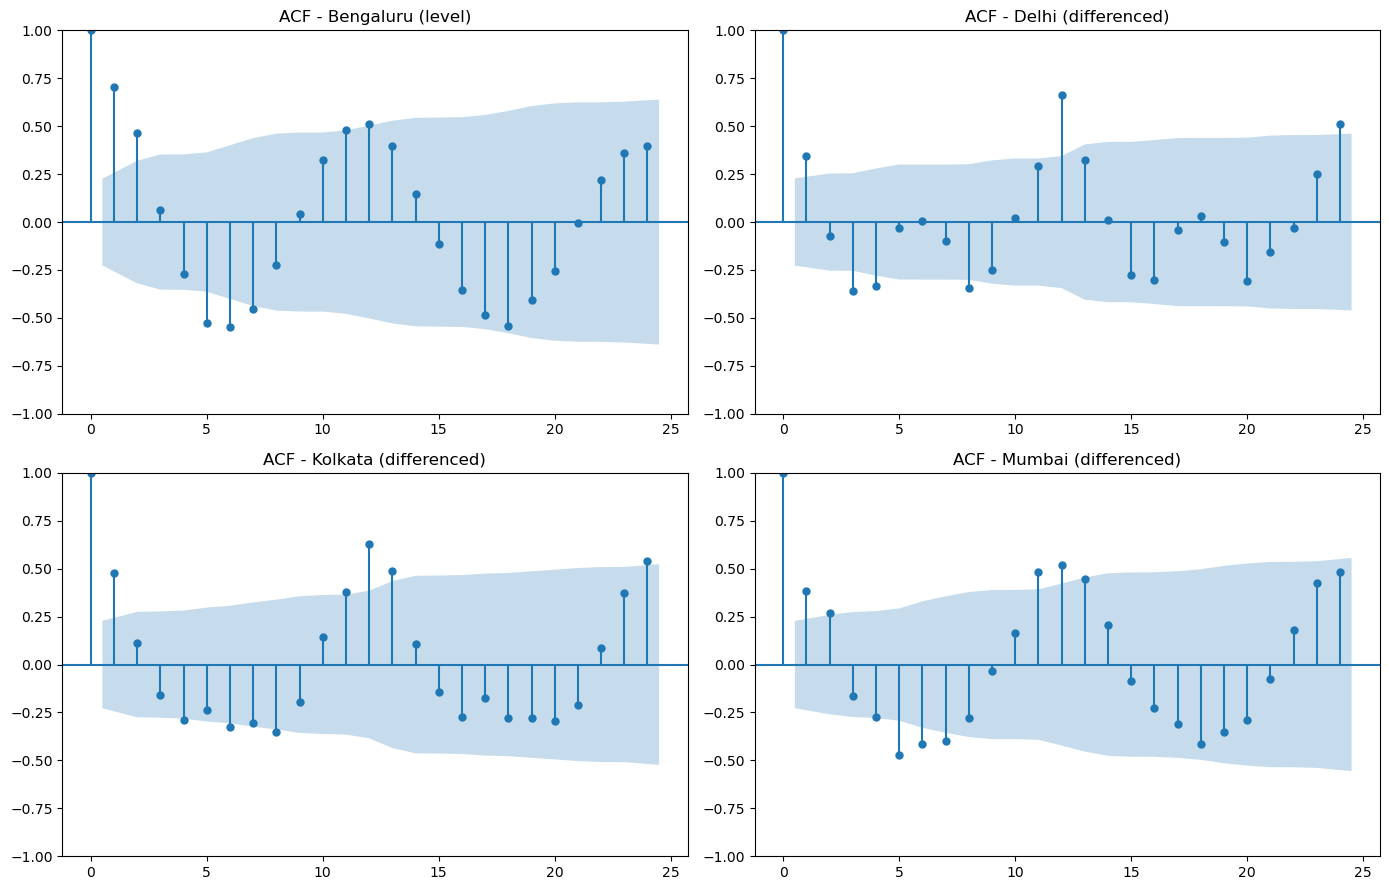

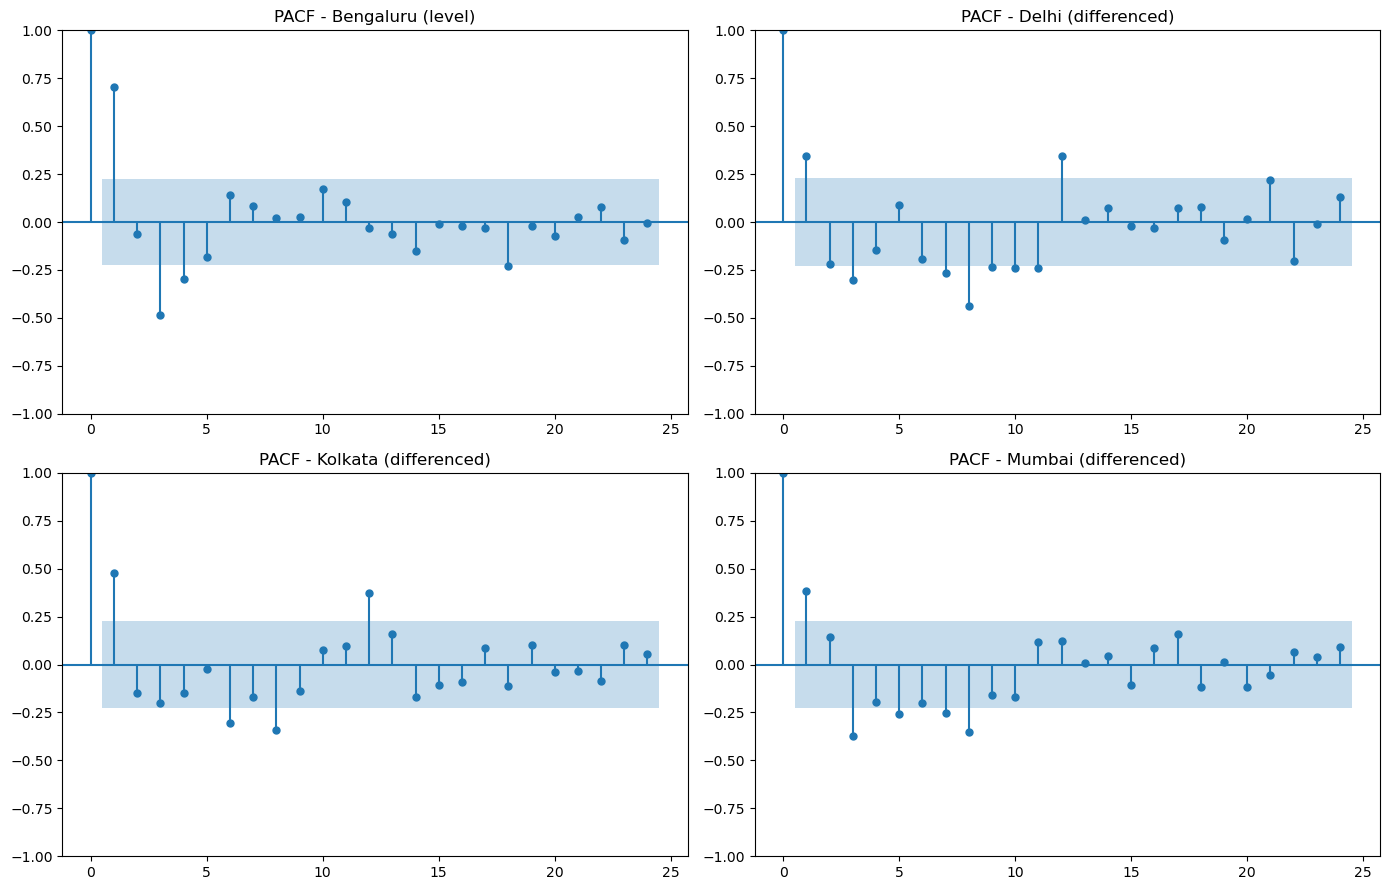

In [13]:
fig_acf, axes_acf = plt.subplots(2, 2, figsize=(14, 9))
fig_pacf, axes_pacf = plt.subplots(2, 2, figsize=(14, 9))

for ax_a, ax_p, city in zip(axes_acf.flat, axes_pacf.flat, cities):
    d, _ = DIFF_ORDERS[city]
    s = city_series(city)
    used = s.diff().dropna() if d == 1 else s
    label = 'differenced' if d == 1 else 'level'
    plot_acf(used, lags=24, ax=ax_a, title=f'ACF - {city} ({label})')
    plot_pacf(used, lags=24, ax=ax_p, method='ywm', title=f'PACF - {city} ({label})')

fig_acf.tight_layout()
fig_pacf.tight_layout()
plt.show()

## 6. AIC grid search (training data only, Jan 2019 – Dec 2023)

p, q, P, Q ∈ {0, 1}, with d and D fixed per city, so every AIC in a city's table is comparable.
The search runs unconstrained (`enforce_* = False`) so the optimiser can explore freely. Whether the final model should be constrained is decided separately in section 7.

In [15]:
def fit_sarima(series, order, seasonal_order, enforce):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        model = SARIMAX(series,
                        order=order,
                        seasonal_order=seasonal_order,
                        enforce_stationarity=enforce,
                        enforce_invertibility=enforce)
        return model.fit(disp=False)

grid_rows = []
for city in cities:
    train = city_series(city)[:TRAIN_END]
    d, D = DIFF_ORDERS[city]
    for p in [0, 1]:
        for q in [0, 1]:
            for P in [0, 1]:
                for Q in [0, 1]:
                    try:
                        fitted = fit_sarima(train, (p, d, q), (P, D, Q, 12), enforce=False)
                        grid_rows.append([city, p, d, q, P, D, Q, fitted.aic])
                    except Exception as e:
                        print(f"{city} ({p},{d},{q})({P},{D},{Q},12) failed: {e}")

grid = pd.DataFrame(grid_rows, columns=['City', 'p', 'd', 'q', 'P', 'D', 'Q', 'AIC'])
top5 = (grid.sort_values(['City', 'AIC'])
            .groupby('City')
            .head(5)
            .reset_index(drop=True))
top5['AIC'] = top5['AIC'].round(2)
top5.to_csv(os.path.join(RESULTS_DIR, "sarima_grid_top5.csv"), index=False)
top5

,City,p,d,q,P,D,Q,AIC
0,Bengaluru,1,0,1,1,0,1,361.75
1,Bengaluru,1,0,1,1,0,0,372.14
2,Bengaluru,1,0,1,0,0,1,373.17
3,Bengaluru,1,0,0,1,0,1,375.80
4,Bengaluru,0,0,1,1,0,1,375.97
5,Delhi,1,1,1,1,1,0,349.70
6,Delhi,1,1,0,1,1,0,356.15
7,Delhi,0,1,1,1,1,0,363.02
8,Delhi,0,1,0,1,1,0,364.76
9,Delhi,1,1,1,0,1,0,468.80


## 7. FIX: choose the `enforce` setting on a validation year

Previously, constraints were switched off because that gave better **test** (2024–25) results, which means the test set was used to make a modelling choice.

Now, for each city's best order:
1. Fit on Jan 2019 – Dec 2022 with constraints on and off.
2. Forecast 2023 (12 months, dynamic) and compare MAE.
3. Keep the setting with the lower validation MAE. If the constrained fit fails, unconstrained is used.

The 2024–25 test data is not touched here.

In [17]:
best_rows = []
for city in cities:
    best = grid[grid['City'] == city].sort_values('AIC').iloc[0]
    order = (int(best['p']), int(best['d']), int(best['q']))
    seasonal_order = (int(best['P']), int(best['D']), int(best['Q']), 12)

    s = city_series(city)
    fit_part = s[:SELECT_END]
    valid = s[VALID_START:TRAIN_END]

    val_mae = {}
    for enforce in [True, False]:
        try:
            fitted = fit_sarima(fit_part, order, seasonal_order, enforce)
            pred = fitted.get_forecast(steps=len(valid)).predicted_mean
            val_mae[enforce] = np.mean(np.abs(valid.values - pred.values))
        except Exception as e:
            print(f"{city} enforce={enforce} failed: {e}")
            val_mae[enforce] = np.nan

    if np.isnan(val_mae[True]):
        chosen = False
    elif np.isnan(val_mae[False]):
        chosen = True
    else:
        chosen = val_mae[True] <= val_mae[False]

    best_rows.append({
        'City': city,
        'p': order[0], 'd': order[1], 'q': order[2],
        'P': seasonal_order[0], 'D': seasonal_order[1], 'Q': seasonal_order[2],
        'AIC': round(best['AIC'], 2),
        'Val_MAE_Constrained': round(val_mae[True], 2),
        'Val_MAE_Unconstrained': round(val_mae[False], 2),
        'Enforce': bool(chosen),
    })

best_models_df = pd.DataFrame(best_rows)
best_models_df.to_csv(os.path.join(RESULTS_DIR, "best_sarima_models.csv"), index=False)
best_models_df

,City,p,d,q,P,D,Q,AIC,Val_MAE_Constrained,Val_MAE_Unconstrained,Enforce
0,Bengaluru,1,0,1,1,0,1,361.75,8.57,9.04,True
1,Delhi,1,1,1,1,1,0,349.70,25.25,24.76,False
2,Kolkata,1,1,1,1,0,1,424.67,25.89,61.31,True
3,Mumbai,0,1,1,1,0,1,404.60,23.34,33.95,True
